# Benchmark Completo: UUID v1 × v4 × v6 × v7 × Snowflake × INT AUTO_INCREMENT
## INSERT + SELECT × Cenários de Índice × Estratégias Otimizadas
**MySQL 8.0 · InnoDB · 4 threads · BINARY(16) · Docker 1GB RAM**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.2,
})

COLORS = {
    "INT AUTO":  "#1f77b4", "UUID v1":   "#d62728", "UUID v4":   "#ff7f0e",
    "UUID v6":   "#9467bd", "UUID v7":   "#2ca02c", "Snowflake": "#17becf",
}
SCENARIOS = ["baseline", "few", "medium", "many"]
ID_TYPES = ["INT AUTO", "UUID v1", "UUID v4", "UUID v6", "UUID v7", "Snowflake"]

def fmt_k(v, _=None):
    return f"{v/1000:.0f}k"

# ══════════════ PARTE 1: INSERT Tipos ══════════════
b1 = pd.DataFrame([
    ("INT AUTO",50000,"baseline",169273),("INT AUTO",50000,"few",128143),
    ("INT AUTO",50000,"medium",101394),("INT AUTO",50000,"many",80615),
    ("INT AUTO",200000,"baseline",218713),("INT AUTO",200000,"few",163302),
    ("INT AUTO",200000,"medium",104408),("INT AUTO",200000,"many",85880),
    ("UUID v1",50000,"baseline",113495),("UUID v1",50000,"few",73812),
    ("UUID v1",50000,"medium",88987),("UUID v1",50000,"many",27367),
    ("UUID v1",200000,"baseline",140255),("UUID v1",200000,"few",125167),
    ("UUID v1",200000,"medium",117593),("UUID v1",200000,"many",82861),
    ("UUID v4",50000,"baseline",103926),("UUID v4",50000,"few",83413),
    ("UUID v4",50000,"medium",70606),("UUID v4",50000,"many",57436),
    ("UUID v4",200000,"baseline",115311),("UUID v4",200000,"few",99779),
    ("UUID v4",200000,"medium",68910),("UUID v4",200000,"many",45198),
    ("UUID v6",50000,"baseline",113589),("UUID v6",50000,"few",97326),
    ("UUID v6",50000,"medium",88712),("UUID v6",50000,"many",74538),
    ("UUID v6",200000,"baseline",127667),("UUID v6",200000,"few",121654),
    ("UUID v6",200000,"medium",111257),("UUID v6",200000,"many",78500),
    ("UUID v7",50000,"baseline",112999),("UUID v7",50000,"few",99624),
    ("UUID v7",50000,"medium",88105),("UUID v7",50000,"many",76197),
    ("UUID v7",200000,"baseline",128730),("UUID v7",200000,"few",119868),
    ("UUID v7",200000,"medium",108812),("UUID v7",200000,"many",83886),
    ("Snowflake",50000,"baseline",166116),("Snowflake",50000,"few",131925),
    ("Snowflake",50000,"medium",75933),("Snowflake",50000,"many",77217),
    ("Snowflake",200000,"baseline",195388),("Snowflake",200000,"few",161000),
    ("Snowflake",200000,"medium",113342),("Snowflake",200000,"many",77373),
], columns=["id_type","rows","scenario","throughput"])

# ══════════════ PARTE 2: INSERT Estratégias (200k) ══════════════
b2 = pd.DataFrame([
    ("INT AUTO","baseline","b100",161990),("INT AUTO","baseline","b1000",224962),
    ("INT AUTO","baseline","b5000",103744),("INT AUTO","baseline","b10000",220346),
    ("INT AUTO","baseline","multi5k",279188),
    ("INT AUTO","few","b100",122374),("INT AUTO","few","b1000",177002),
    ("INT AUTO","few","b5000",179225),("INT AUTO","few","b10000",169828),
    ("INT AUTO","few","multi5k",193223),
    ("INT AUTO","medium","b100",92835),("INT AUTO","medium","b1000",122349),
    ("INT AUTO","medium","b5000",127679),("INT AUTO","medium","b10000",119215),
    ("INT AUTO","medium","multi5k",117271),
    ("INT AUTO","many","b100",60640),("INT AUTO","many","b1000",83210),
    ("INT AUTO","many","b5000",87653),("INT AUTO","many","b10000",82787),
    ("INT AUTO","many","multi5k",89234),
    ("UUID v4","baseline","b100",80751),("UUID v4","baseline","b1000",112663),
    ("UUID v4","baseline","b5000",109845),("UUID v4","baseline","b10000",109610),
    ("UUID v4","baseline","multi5k",124811),
    ("UUID v4","baseline","sorted5k",113050),("UUID v4","baseline","sort+mr",122808),
    ("UUID v4","few","b100",71223),("UUID v4","few","b1000",98313),
    ("UUID v4","few","b5000",97526),("UUID v4","few","b10000",90906),
    ("UUID v4","few","multi5k",104002),
    ("UUID v4","few","sorted5k",104300),("UUID v4","few","sort+mr",101968),
    ("UUID v4","medium","b100",53200),("UUID v4","medium","b1000",68009),
    ("UUID v4","medium","b5000",69788),("UUID v4","medium","b10000",65703),
    ("UUID v4","medium","multi5k",69685),
    ("UUID v4","medium","sorted5k",78384),("UUID v4","medium","sort+mr",82164),
    ("UUID v4","many","b100",36559),("UUID v4","many","b1000",44591),
    ("UUID v4","many","b5000",47125),("UUID v4","many","b10000",44967),
    ("UUID v4","many","multi5k",47084),
    ("UUID v4","many","sorted5k",48776),("UUID v4","many","sort+mr",48714),
    ("UUID v7","baseline","b100",93953),("UUID v7","baseline","b1000",126762),
    ("UUID v7","baseline","b5000",132174),("UUID v7","baseline","b10000",127300),
    ("UUID v7","baseline","multi5k",139833),
    ("UUID v7","few","b100",84322),("UUID v7","few","b1000",119022),
    ("UUID v7","few","b5000",123005),("UUID v7","few","b10000",110427),
    ("UUID v7","few","multi5k",128207),
    ("UUID v7","medium","b100",68942),("UUID v7","medium","b1000",107793),
    ("UUID v7","medium","b5000",112398),("UUID v7","medium","b10000",100068),
    ("UUID v7","medium","multi5k",114734),
    ("UUID v7","many","b100",64260),("UUID v7","many","b1000",79776),
    ("UUID v7","many","b5000",72737),("UUID v7","many","b10000",76874),
    ("UUID v7","many","multi5k",84341),
    ("Snowflake","baseline","b100",129013),("Snowflake","baseline","b1000",192730),
    ("Snowflake","baseline","b5000",205881),("Snowflake","baseline","b10000",200496),
    ("Snowflake","baseline","multi5k",224247),
    ("Snowflake","few","b100",110323),("Snowflake","few","b1000",151324),
    ("Snowflake","few","b5000",165709),("Snowflake","few","b10000",157126),
    ("Snowflake","few","multi5k",164002),
    ("Snowflake","medium","b100",83626),("Snowflake","medium","b1000",109280),
    ("Snowflake","medium","b5000",109468),("Snowflake","medium","b10000",110050),
    ("Snowflake","medium","multi5k",115852),
    ("Snowflake","many","b100",62557),("Snowflake","many","b1000",76235),
    ("Snowflake","many","b5000",81826),("Snowflake","many","b10000",78933),
    ("Snowflake","many","multi5k",80317),
], columns=["id_type","scenario","strategy","throughput"])

# ══════════════ PARTE 3: SELECT (200k) ══════════════
b3 = pd.DataFrame([
    ("INT AUTO","baseline","point_lookup",41.639),("INT AUTO","baseline","range_scan",53.578),
    ("INT AUTO","baseline","order_by",52.514),("INT AUTO","baseline","count_group_by",96.453),
    ("INT AUTO","baseline","full_scan_count",24.640),
    ("INT AUTO","few","point_lookup",0.572),("INT AUTO","few","range_scan",58.502),
    ("INT AUTO","few","order_by",51.270),("INT AUTO","few","count_group_by",39.522),
    ("INT AUTO","few","full_scan_count",11.609),
    ("INT AUTO","medium","point_lookup",0.583),("INT AUTO","medium","range_scan",59.485),
    ("INT AUTO","medium","order_by",43.969),("INT AUTO","medium","count_group_by",40.189),
    ("INT AUTO","medium","full_scan_count",14.273),
    ("INT AUTO","many","point_lookup",0.747),("INT AUTO","many","range_scan",59.720),
    ("INT AUTO","many","order_by",26.328),("INT AUTO","many","count_group_by",41.651),
    ("INT AUTO","many","full_scan_count",12.549),
    ("UUID v1","baseline","point_lookup",41.341),("UUID v1","baseline","range_scan",190.981),
    ("UUID v1","baseline","order_by",3.281),("UUID v1","baseline","count_group_by",343.118),
    ("UUID v1","baseline","full_scan_count",25.108),
    ("UUID v1","few","point_lookup",0.577),("UUID v1","few","range_scan",181.171),
    ("UUID v1","few","order_by",3.293),("UUID v1","few","count_group_by",62.537),
    ("UUID v1","few","full_scan_count",12.435),
    ("UUID v1","medium","point_lookup",0.590),("UUID v1","medium","range_scan",160.827),
    ("UUID v1","medium","order_by",3.310),("UUID v1","medium","count_group_by",62.740),
    ("UUID v1","medium","full_scan_count",10.967),
    ("UUID v1","many","point_lookup",0.583),("UUID v1","many","range_scan",199.526),
    ("UUID v1","many","order_by",3.363),("UUID v1","many","count_group_by",62.764),
    ("UUID v1","many","full_scan_count",10.250),
    ("UUID v4","baseline","point_lookup",45.799),("UUID v4","baseline","range_scan",184.424),
    ("UUID v4","baseline","order_by",3.379),("UUID v4","baseline","count_group_by",442.586),
    ("UUID v4","baseline","full_scan_count",30.470),
    ("UUID v4","few","point_lookup",0.584),("UUID v4","few","range_scan",152.754),
    ("UUID v4","few","order_by",3.339),("UUID v4","few","count_group_by",65.808),
    ("UUID v4","few","full_scan_count",11.675),
    ("UUID v4","medium","point_lookup",0.606),("UUID v4","medium","range_scan",219.161),
    ("UUID v4","medium","order_by",3.335),("UUID v4","medium","count_group_by",65.301),
    ("UUID v4","medium","full_scan_count",13.939),
    ("UUID v4","many","point_lookup",0.613),("UUID v4","many","range_scan",202.505),
    ("UUID v4","many","order_by",3.327),("UUID v4","many","count_group_by",64.952),
    ("UUID v4","many","full_scan_count",11.318),
    ("UUID v6","baseline","point_lookup",41.280),("UUID v6","baseline","range_scan",220.324),
    ("UUID v6","baseline","order_by",3.562),("UUID v6","baseline","count_group_by",368.281),
    ("UUID v6","baseline","full_scan_count",24.637),
    ("UUID v6","few","point_lookup",0.659),("UUID v6","few","range_scan",212.610),
    ("UUID v6","few","order_by",3.388),("UUID v6","few","count_group_by",63.108),
    ("UUID v6","few","full_scan_count",12.936),
    ("UUID v6","medium","point_lookup",0.582),("UUID v6","medium","range_scan",173.441),
    ("UUID v6","medium","order_by",3.308),("UUID v6","medium","count_group_by",62.653),
    ("UUID v6","medium","full_scan_count",12.699),
    ("UUID v6","many","point_lookup",0.567),("UUID v6","many","range_scan",196.056),
    ("UUID v6","many","order_by",3.594),("UUID v6","many","count_group_by",62.643),
    ("UUID v6","many","full_scan_count",10.623),
    ("UUID v7","baseline","point_lookup",41.304),("UUID v7","baseline","range_scan",203.817),
    ("UUID v7","baseline","order_by",3.581),("UUID v7","baseline","count_group_by",352.116),
    ("UUID v7","baseline","full_scan_count",24.243),
    ("UUID v7","few","point_lookup",0.566),("UUID v7","few","range_scan",174.865),
    ("UUID v7","few","order_by",3.301),("UUID v7","few","count_group_by",62.434),
    ("UUID v7","few","full_scan_count",15.430),
    ("UUID v7","medium","point_lookup",0.644),("UUID v7","medium","range_scan",198.590),
    ("UUID v7","medium","order_by",3.433),("UUID v7","medium","count_group_by",64.467),
    ("UUID v7","medium","full_scan_count",11.010),
    ("UUID v7","many","point_lookup",0.599),("UUID v7","many","range_scan",241.076),
    ("UUID v7","many","order_by",3.977),("UUID v7","many","count_group_by",63.624),
    ("UUID v7","many","full_scan_count",11.356),
    ("Snowflake","baseline","point_lookup",42.473),("Snowflake","baseline","range_scan",54.422),
    ("Snowflake","baseline","order_by",3.577),("Snowflake","baseline","count_group_by",94.565),
    ("Snowflake","baseline","full_scan_count",24.285),
    ("Snowflake","few","point_lookup",0.585),("Snowflake","few","range_scan",57.952),
    ("Snowflake","few","order_by",3.810),("Snowflake","few","count_group_by",42.051),
    ("Snowflake","few","full_scan_count",13.451),
    ("Snowflake","medium","point_lookup",0.650),("Snowflake","medium","range_scan",57.300),
    ("Snowflake","medium","order_by",3.435),("Snowflake","medium","count_group_by",40.190),
    ("Snowflake","medium","full_scan_count",11.722),
    ("Snowflake","many","point_lookup",0.562),("Snowflake","many","range_scan",57.826),
    ("Snowflake","many","order_by",3.568),("Snowflake","many","count_group_by",41.103),
    ("Snowflake","many","full_scan_count",12.286),
], columns=["id_type","scenario","query","avg_ms"])

STRATS = ["b100","b1000","b5000","b10000","multi5k"]
STRAT_LABELS = ["batch 100","batch 1k","batch 5k","batch 10k","multi-row\n5k"]

print("Dados carregados: P1 INSERT tipos, P2 INSERT estrategias, P3 SELECT")

Dados carregados: P1 INSERT tipos, P2 INSERT estrategias, P3 SELECT


## 1. Throughput vs Índices - INSERT 200k rows

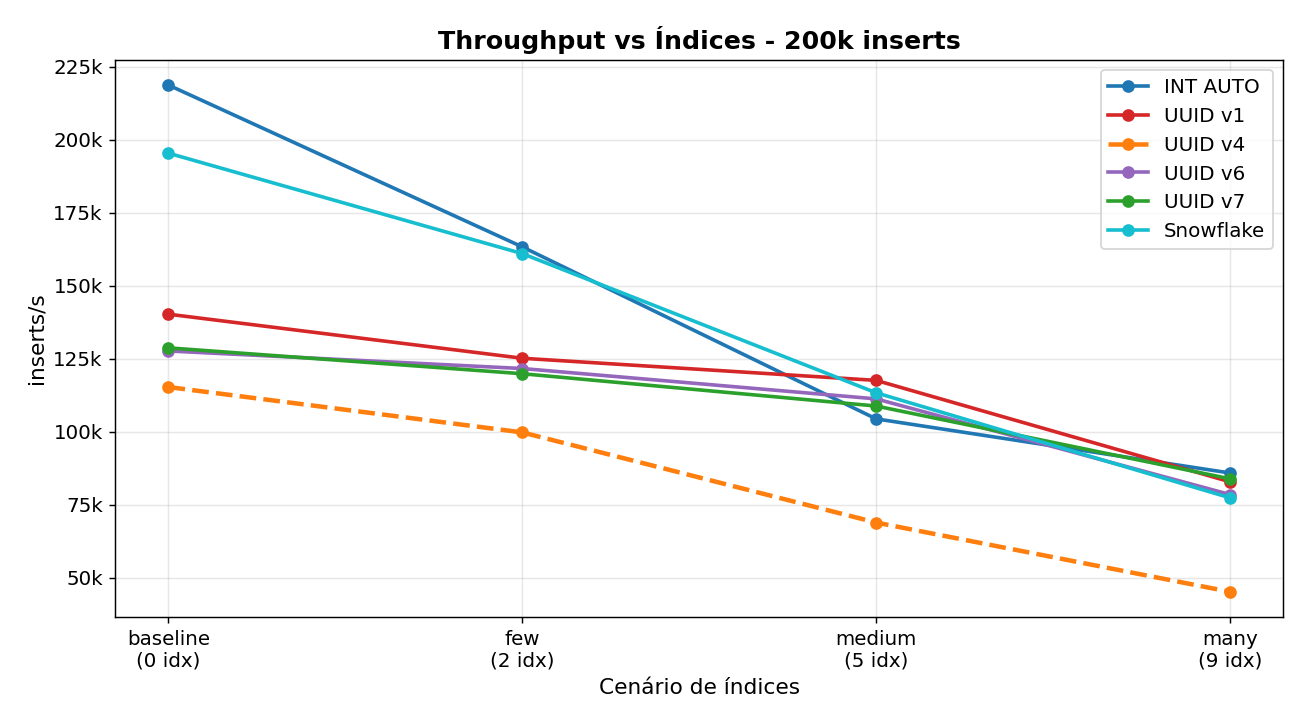

In [2]:
fig, ax = plt.subplots()
ax.set_title("Throughput vs Índices - 200k inserts")
df = b1[b1["rows"] == 200000]
x = np.arange(len(SCENARIOS))
for idt in ID_TYPES:
    sub = df[df["id_type"] == idt].set_index("scenario").reindex(SCENARIOS)
    style = {"linewidth": 2, "marker": "o", "markersize": 6, "color": COLORS[idt]}
    if idt == "UUID v4":
        style.update({"linestyle": "--", "linewidth": 2.5})
    ax.plot(x, sub["throughput"].values, label=idt, **style)
ax.set_xticks(x)
ax.set_xticklabels(["baseline\n(0 idx)", "few\n(2 idx)", "medium\n(5 idx)", "many\n(9 idx)"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")
ax.set_xlabel("Cenário de índices")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("01_throughput_lines_200k.png")
plt.show()

## 2. Throughput vs Índices - INSERT 50k rows

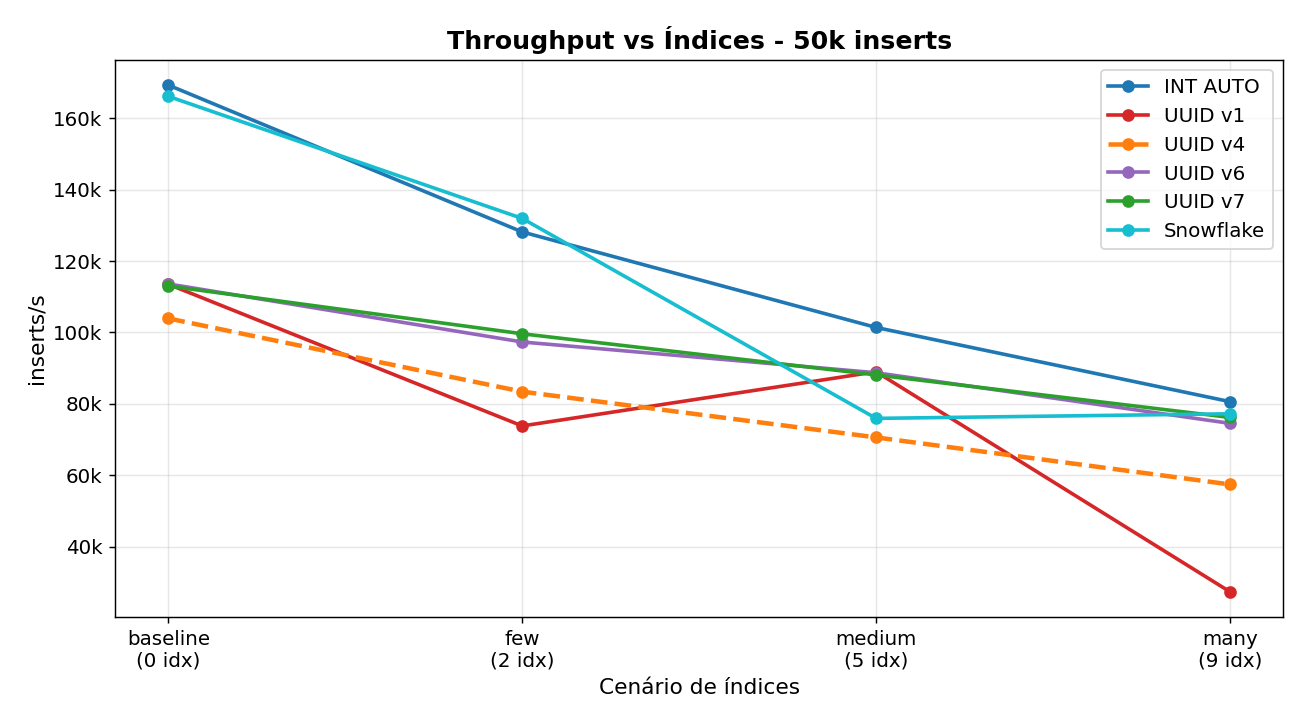

In [3]:
fig, ax = plt.subplots()
ax.set_title("Throughput vs Índices - 50k inserts")
df = b1[b1["rows"] == 50000]
x = np.arange(len(SCENARIOS))
for idt in ID_TYPES:
    sub = df[df["id_type"] == idt].set_index("scenario").reindex(SCENARIOS)
    style = {"linewidth": 2, "marker": "o", "markersize": 6, "color": COLORS[idt]}
    if idt == "UUID v4":
        style.update({"linestyle": "--", "linewidth": 2.5})
    ax.plot(x, sub["throughput"].values, label=idt, **style)
ax.set_xticks(x)
ax.set_xticklabels(["baseline\n(0 idx)", "few\n(2 idx)", "medium\n(5 idx)", "many\n(9 idx)"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")
ax.set_xlabel("Cenário de índices")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("02_throughput_lines_50k.png")
plt.show()

## 3. Baseline vs Many - 200k rows

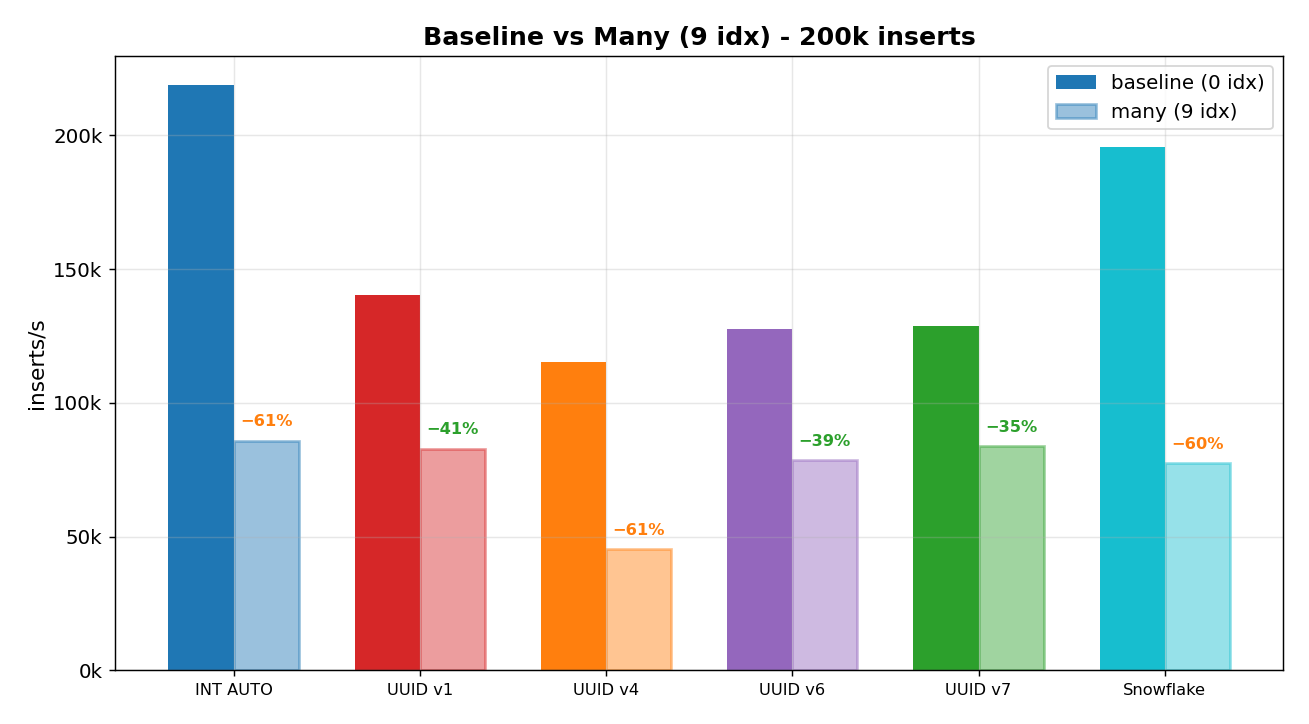

In [4]:
fig, ax = plt.subplots()
ax.set_title("Baseline vs Many (9 idx) - 200k inserts")
df = b1[b1["rows"] == 200000]
x = np.arange(len(ID_TYPES))
w = 0.35
base_vals = [df[(df["id_type"]==t)&(df["scenario"]=="baseline")]["throughput"].values[0] for t in ID_TYPES]
many_vals = [df[(df["id_type"]==t)&(df["scenario"]=="many")]["throughput"].values[0] for t in ID_TYPES]
ax.bar(x - w/2, base_vals, w, label="baseline (0 idx)", color=[COLORS[t] for t in ID_TYPES])
ax.bar(x + w/2, many_vals, w, label="many (9 idx)", color=[COLORS[t] for t in ID_TYPES],
       alpha=0.45, edgecolor=[COLORS[t] for t in ID_TYPES], linewidth=1.5)
for i in range(len(ID_TYPES)):
    drop = (base_vals[i] - many_vals[i]) / base_vals[i] * 100
    color = "#d62728" if drop > 70 else "#ff7f0e" if drop > 50 else "#2ca02c"
    ax.annotate(f"\u2212{drop:.0f}%", xy=(x[i]+w/2, many_vals[i]),
                xytext=(0,8), textcoords="offset points",
                ha="center", fontsize=9, fontweight="bold", color=color)
ax.set_xticks(x)
ax.set_xticklabels(ID_TYPES, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")
ax.legend()
plt.tight_layout()
plt.savefig("03_baseline_vs_many_200k.png")
plt.show()

## 4. Queda percentual de throughput: baseline → many

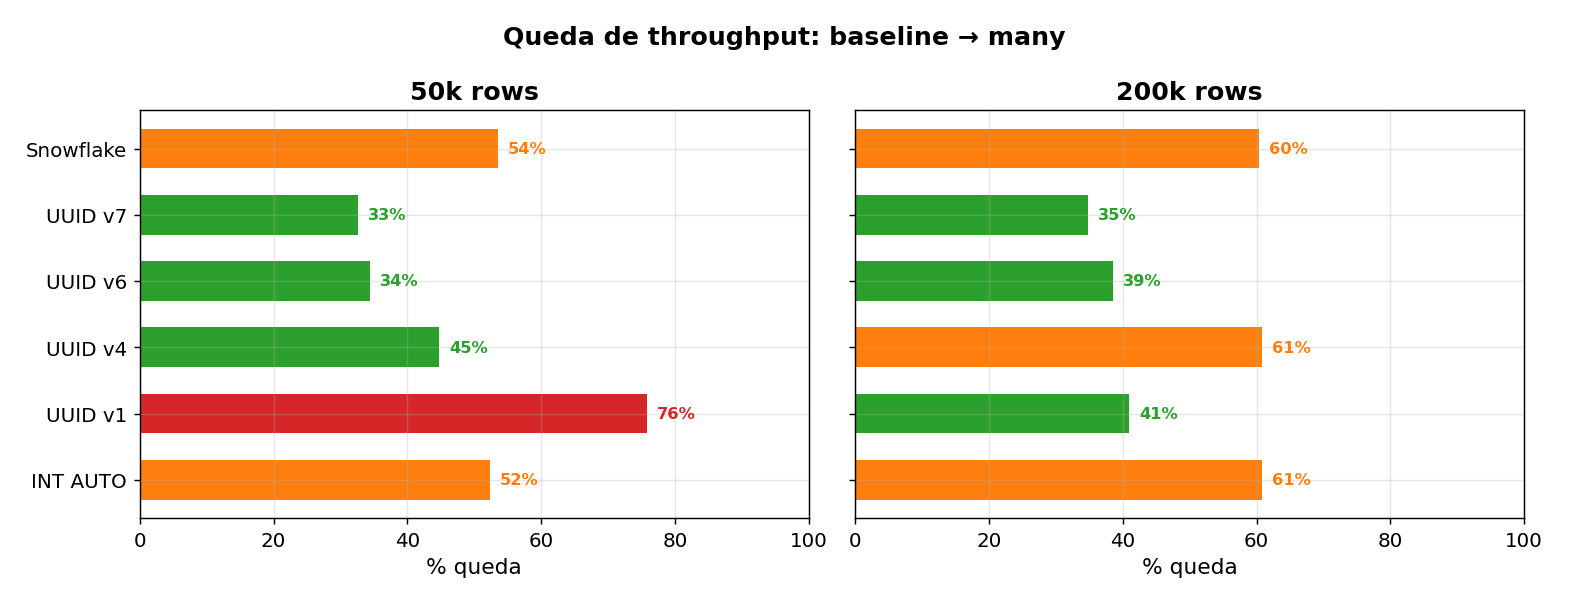

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
fig.suptitle("Queda de throughput: baseline → many", fontsize=14, fontweight="bold")
for ax, rows, title in zip(axes, [50000, 200000], ["50k rows", "200k rows"]):
    df = b1[b1["rows"] == rows]
    drops = []
    for t in ID_TYPES:
        base = df[(df["id_type"]==t)&(df["scenario"]=="baseline")]["throughput"].values[0]
        many = df[(df["id_type"]==t)&(df["scenario"]=="many")]["throughput"].values[0]
        drops.append((base - many) / base * 100)
    y = np.arange(len(ID_TYPES))
    bar_colors = ["#d62728" if d>70 else "#ff7f0e" if d>50 else "#2ca02c" for d in drops]
    ax.barh(y, drops, color=bar_colors, height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(ID_TYPES)
    ax.set_xlabel("% queda"); ax.set_title(title); ax.set_xlim(0, 100)
    for i, d in enumerate(drops):
        ax.text(d+1.5, i, f"{d:.0f}%", va="center", fontsize=9, fontweight="bold", color=bar_colors[i])
plt.tight_layout()
plt.savefig("04_degradation_pct.png")
plt.show()

## 5. Efeito do Batch Size - 200k rows, baseline

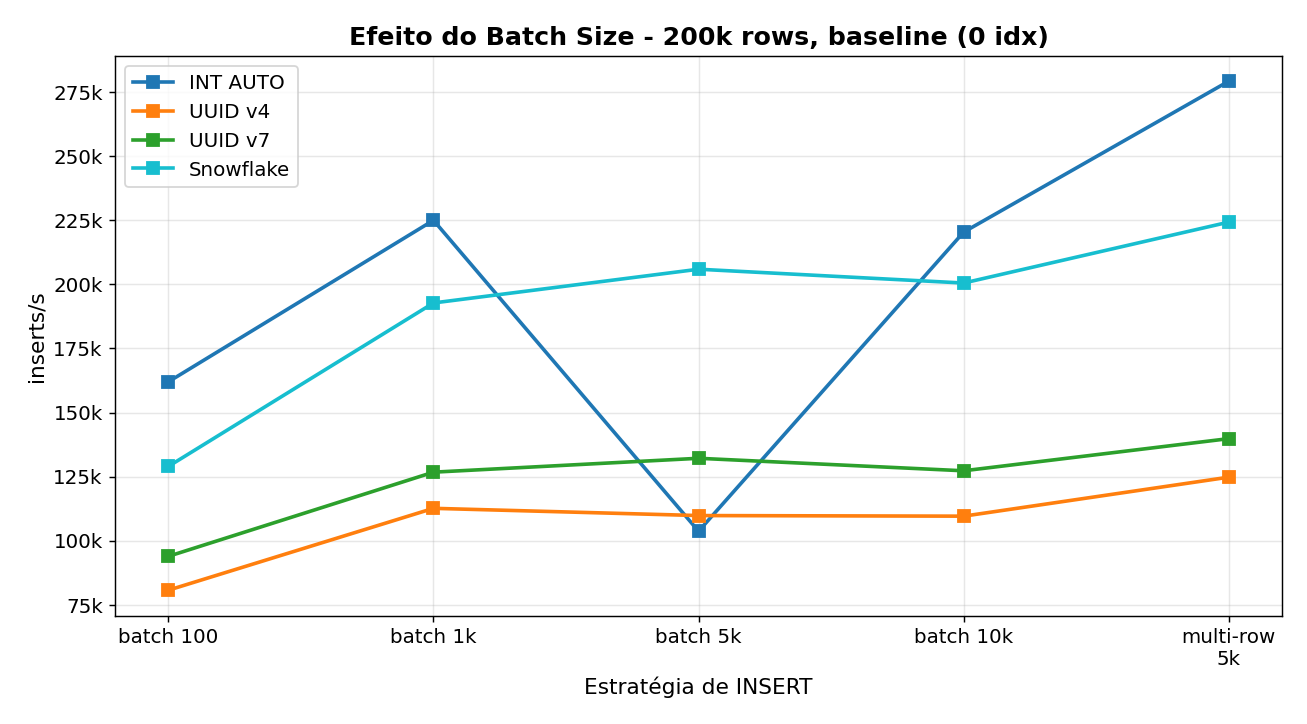

In [6]:
fig, ax = plt.subplots()
ax.set_title("Efeito do Batch Size - 200k rows, baseline (0 idx)")
x = np.arange(len(STRATS))
for idt in ["INT AUTO", "UUID v4", "UUID v7", "Snowflake"]:
    sub = b2[(b2["id_type"]==idt)&(b2["scenario"]=="baseline")]
    vals = [sub[sub["strategy"]==s]["throughput"].values[0] for s in STRATS]
    ax.plot(x, vals, color=COLORS[idt], linewidth=2, marker="s", markersize=7, label=idt)
ax.set_xticks(x); ax.set_xticklabels(STRAT_LABELS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s"); ax.set_xlabel("Estratégia de INSERT")
ax.legend()
plt.tight_layout()
plt.savefig("05_batch_effect_baseline.png")
plt.show()

## 6. Efeito do Batch Size - 200k rows, many (9 idx)

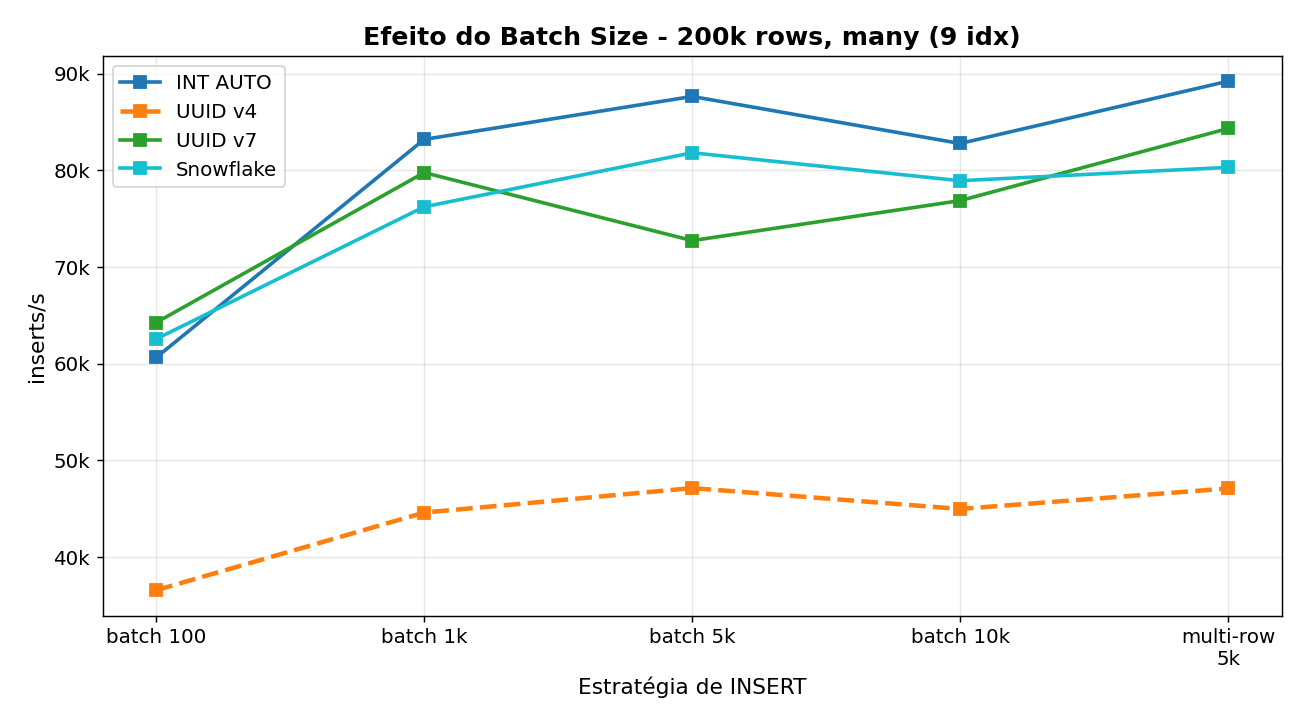

In [7]:
fig, ax = plt.subplots()
ax.set_title("Efeito do Batch Size - 200k rows, many (9 idx)")
x = np.arange(len(STRATS))
for idt in ["INT AUTO", "UUID v4", "UUID v7", "Snowflake"]:
    sub = b2[(b2["id_type"]==idt)&(b2["scenario"]=="many")]
    vals = [sub[sub["strategy"]==s]["throughput"].values[0] for s in STRATS]
    ls = "--" if idt == "UUID v4" else "-"
    lw = 2.5 if idt == "UUID v4" else 2
    ax.plot(x, vals, color=COLORS[idt], linewidth=lw, linestyle=ls,
            marker="s", markersize=7, label=idt)
ax.set_xticks(x); ax.set_xticklabels(STRAT_LABELS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s"); ax.set_xlabel("Estratégia de INSERT")
ax.legend()
plt.tight_layout()
plt.savefig("06_batch_effect_many.png")
plt.show()

## 7. UUID v4: Impacto do Sort Prévio - 200k rows, many

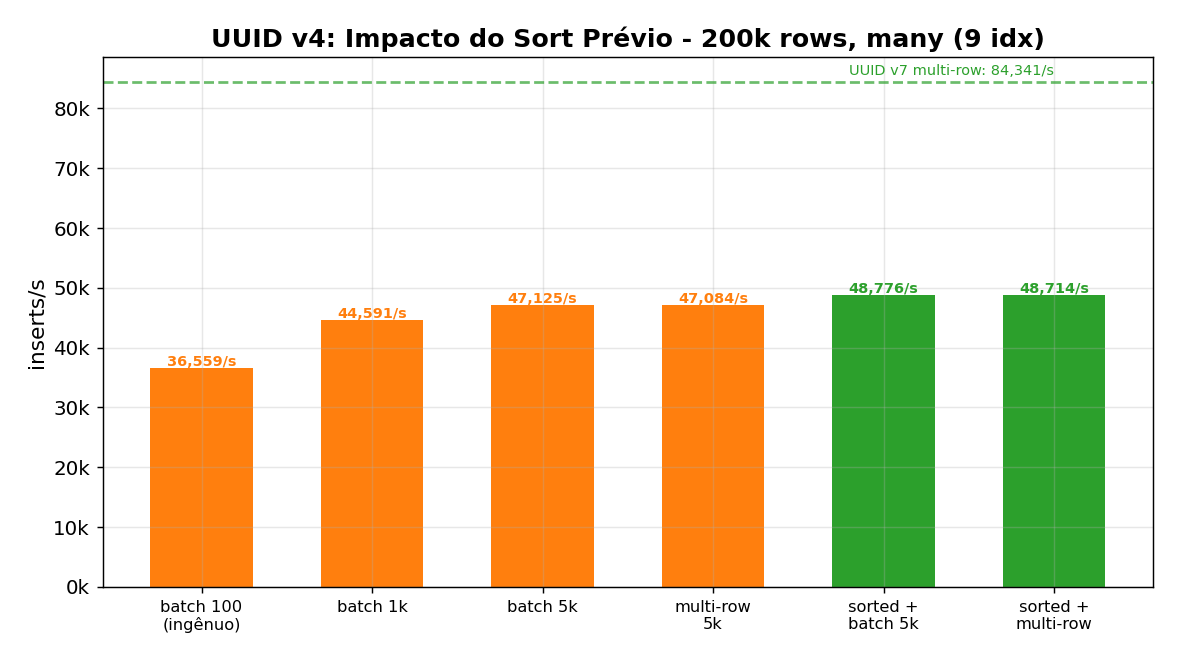

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title("UUID v4: Impacto do Sort Prévio - 200k rows, many (9 idx)")
v4_strats = [("b100","batch 100\n(ingênuo)"),("b1000","batch 1k"),("b5000","batch 5k"),
             ("multi5k","multi-row\n5k"),("sorted5k","sorted +\nbatch 5k"),("sort+mr","sorted +\nmulti-row")]
sub = b2[(b2["id_type"]=="UUID v4")&(b2["scenario"]=="many")]
vals = [sub[sub["strategy"]==s[0]]["throughput"].values[0] for s in v4_strats]
labels = [s[1] for s in v4_strats]
bar_colors = ["#ff7f0e"]*4 + ["#2ca02c"]*2
ax.bar(range(len(vals)), vals, color=bar_colors, width=0.6)
ax.set_xticks(range(len(vals))); ax.set_xticklabels(labels, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s")
for i, v in enumerate(vals):
    ax.text(i, v+400, f"{v:,}/s", ha="center", fontsize=8, fontweight="bold", color=bar_colors[i])
v7_ref = b2[(b2["id_type"]=="UUID v7")&(b2["scenario"]=="many")&(b2["strategy"]=="multi5k")]["throughput"].values[0]
ax.axhline(y=v7_ref, color=COLORS["UUID v7"], linestyle="--", linewidth=1.5, alpha=0.7)
ax.text(5, v7_ref+1200, f"UUID v7 multi-row: {v7_ref:,}/s", fontsize=8, color=COLORS["UUID v7"], ha="right")
plt.tight_layout()
plt.savefig("07_v4_sort_impact.png")
plt.show()

## 8. Pior vs Melhor Estratégia - 200k rows, many

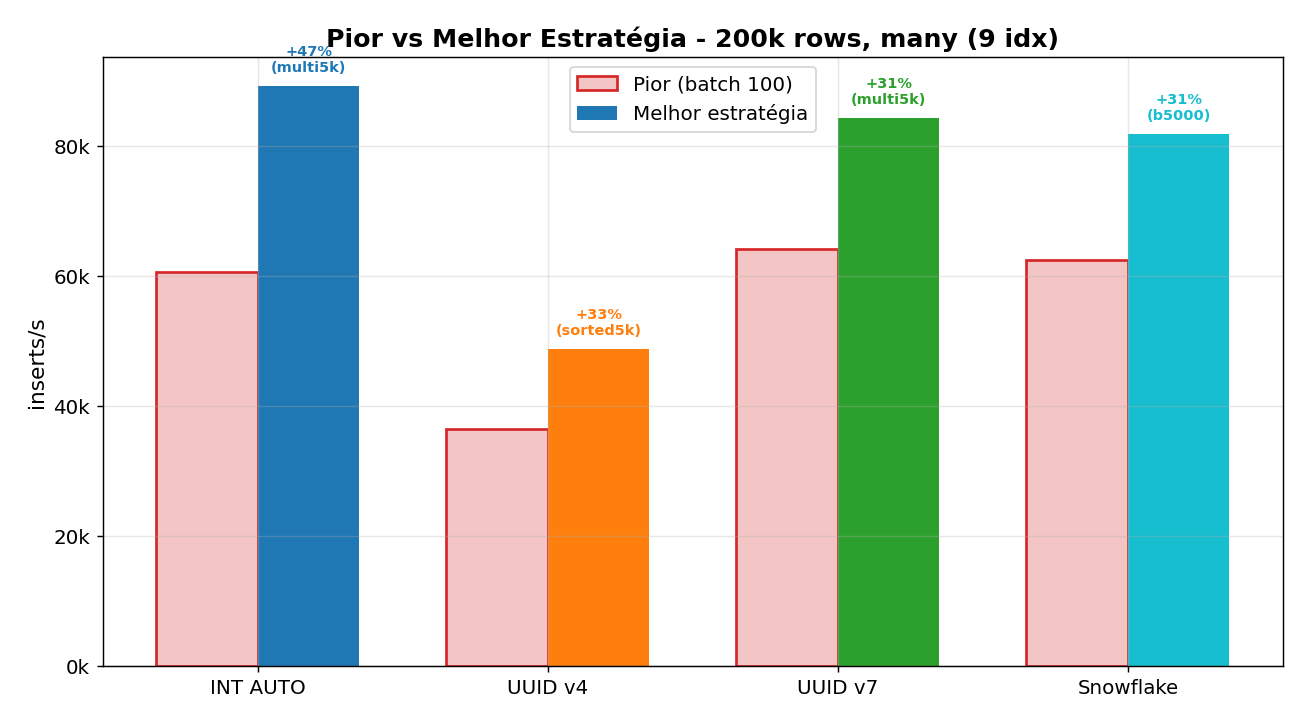

In [9]:
fig, ax = plt.subplots()
ax.set_title("Pior vs Melhor Estratégia - 200k rows, many (9 idx)")
types_show = ["INT AUTO", "UUID v4", "UUID v7", "Snowflake"]
worst = {t: b2[(b2["id_type"]==t)&(b2["scenario"]=="many")&(b2["strategy"]=="b100")]["throughput"].values[0] for t in types_show}
best_map = {"INT AUTO":"multi5k", "UUID v4":"sorted5k", "UUID v7":"multi5k", "Snowflake":"b5000"}
best = {t: b2[(b2["id_type"]==t)&(b2["scenario"]=="many")&(b2["strategy"]==best_map[t])]["throughput"].values[0] for t in types_show}
x = np.arange(len(types_show)); w = 0.35
ax.bar(x-w/2, [worst[t] for t in types_show], w, label="Pior (batch 100)",
       color="#d6272844", edgecolor="#d62728", linewidth=1.5)
ax.bar(x+w/2, [best[t] for t in types_show], w, label="Melhor estratégia",
       color=[COLORS[t] for t in types_show])
for i, t in enumerate(types_show):
    gain = (best[t]-worst[t])/worst[t]*100
    ax.annotate(f"+{gain:.0f}%\n({best_map[t]})", xy=(x[i]+w/2, best[t]),
                xytext=(0,8), textcoords="offset points", ha="center",
                fontsize=8, fontweight="bold", color=COLORS[t])
ax.set_xticks(x); ax.set_xticklabels(types_show)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s"); ax.legend()
plt.tight_layout()
plt.savefig("08_best_vs_worst.png")
plt.show()

## 9. SELECT: Point Lookup - baseline vs com índice

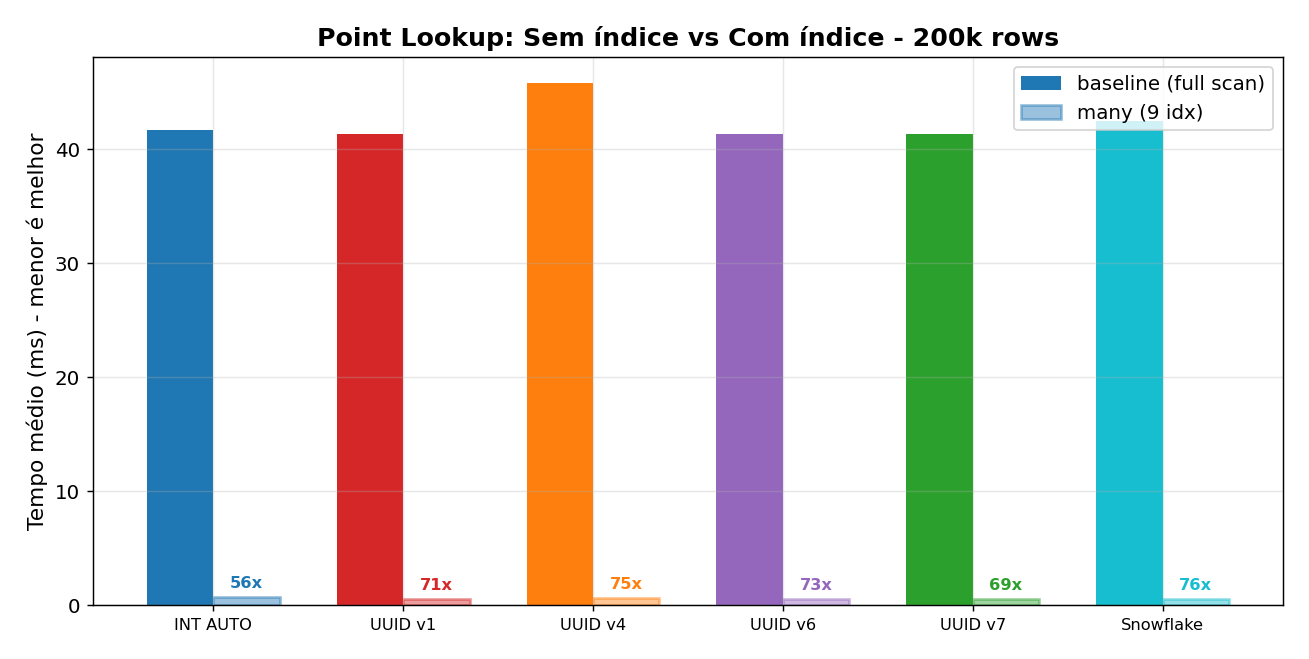

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Point Lookup: Sem índice vs Com índice - 200k rows")
sub = b3[b3["query"] == "point_lookup"]
x = np.arange(len(ID_TYPES)); w = 0.35
base_vals = [sub[(sub["id_type"]==t)&(sub["scenario"]=="baseline")]["avg_ms"].values[0] for t in ID_TYPES]
many_vals = [sub[(sub["id_type"]==t)&(sub["scenario"]=="many")]["avg_ms"].values[0] for t in ID_TYPES]
ax.bar(x-w/2, base_vals, w, label="baseline (full scan)", color=[COLORS[t] for t in ID_TYPES])
ax.bar(x+w/2, many_vals, w, label="many (9 idx)", color=[COLORS[t] for t in ID_TYPES],
       alpha=0.45, edgecolor=[COLORS[t] for t in ID_TYPES], linewidth=1.5)
for i in range(len(ID_TYPES)):
    speedup = base_vals[i] / many_vals[i]
    ax.annotate(f"{speedup:.0f}x", xy=(x[i]+w/2, many_vals[i]),
                xytext=(0,5), textcoords="offset points", ha="center",
                fontsize=9, fontweight="bold", color=COLORS[ID_TYPES[i]])
ax.set_xticks(x); ax.set_xticklabels(ID_TYPES, fontsize=9)
ax.set_ylabel("Tempo médio (ms) - menor é melhor")
ax.legend()
plt.tight_layout()
plt.savefig("09_select_point_lookup.png")
plt.show()

## 10. SELECT: Todas as queries - baseline vs many

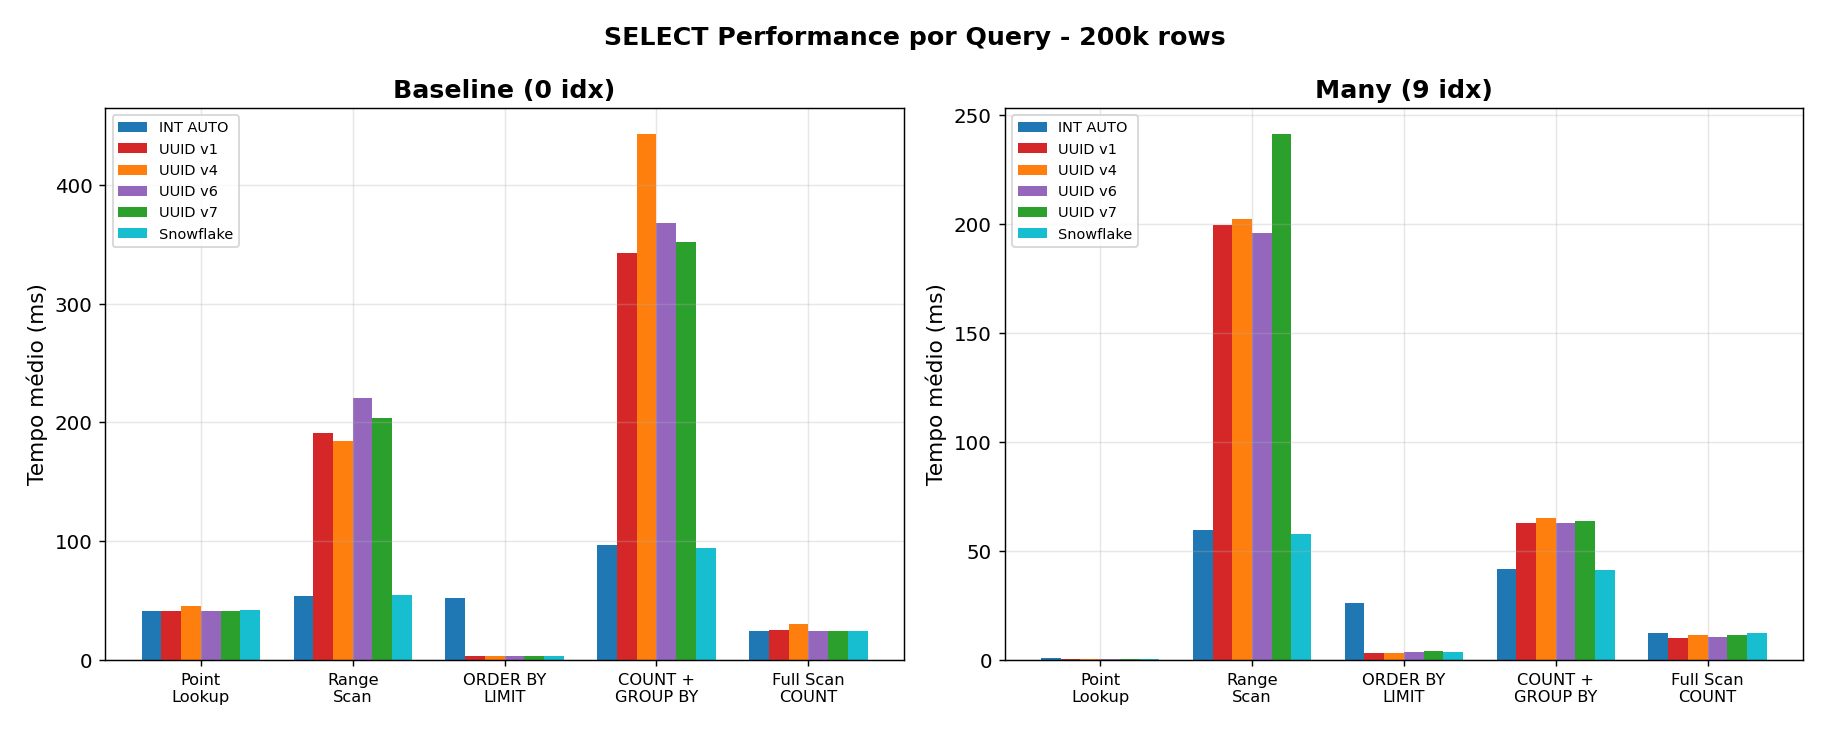

In [11]:
queries = ["point_lookup", "range_scan", "order_by", "count_group_by", "full_scan_count"]
q_labels = ["Point\nLookup", "Range\nScan", "ORDER BY\nLIMIT", "COUNT +\nGROUP BY", "Full Scan\nCOUNT"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
fig.suptitle("SELECT Performance por Query - 200k rows", fontsize=14, fontweight="bold")

for ax, sc, title in zip(axes, ["baseline", "many"], ["Baseline (0 idx)", "Many (9 idx)"]):
    sub = b3[b3["scenario"] == sc]
    x = np.arange(len(queries))
    width = 0.13
    for i, idt in enumerate(ID_TYPES):
        vals = []
        for q in queries:
            row = sub[(sub["id_type"]==idt)&(sub["query"]==q)]
            vals.append(row["avg_ms"].values[0] if len(row) > 0 else 0)
        ax.bar(x + i*width - width*2.5, vals, width, label=idt, color=COLORS[idt])
    ax.set_xticks(x); ax.set_xticklabels(q_labels, fontsize=9)
    ax.set_ylabel("Tempo médio (ms)"); ax.set_title(title)
    ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("10_select_all_queries.png")
plt.show()

## 11. COUNT + GROUP BY: O ganho mais dramático com índices

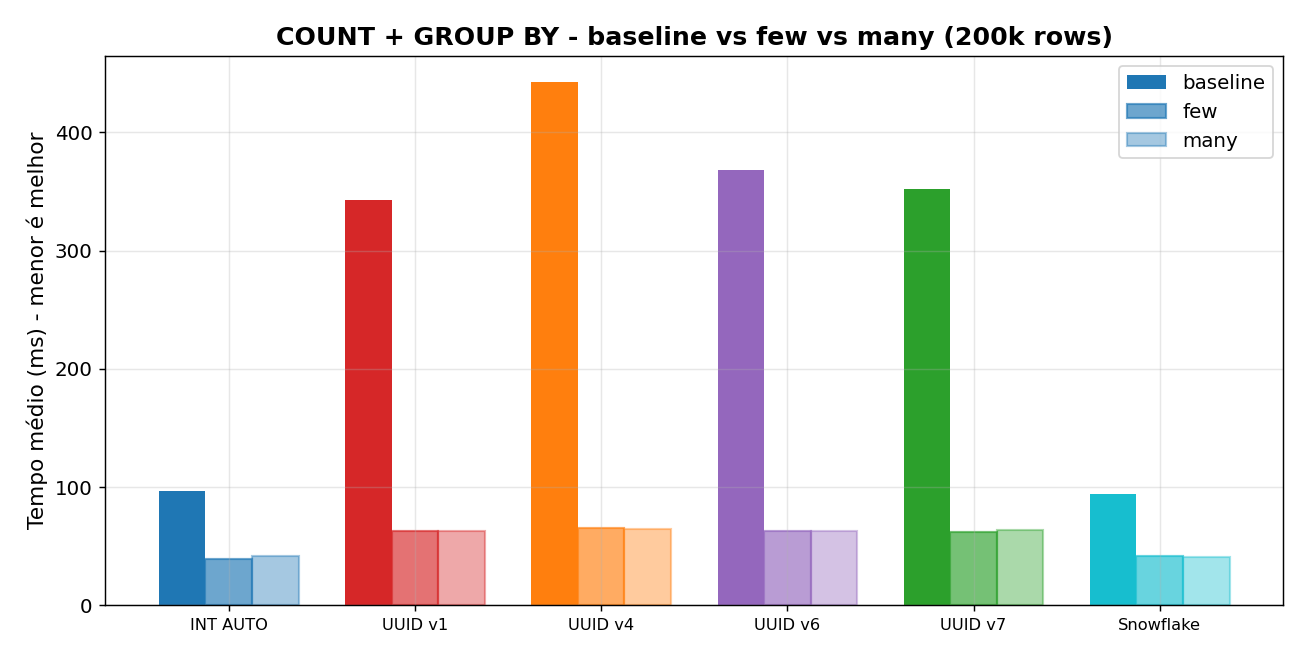

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("COUNT + GROUP BY - baseline vs few vs many (200k rows)")
sub = b3[b3["query"] == "count_group_by"]
x = np.arange(len(ID_TYPES))
w = 0.25
for i, (sc, alpha) in enumerate([("baseline", 1.0), ("few", 0.65), ("many", 0.4)]):
    vals = [sub[(sub["id_type"]==t)&(sub["scenario"]==sc)]["avg_ms"].values[0] for t in ID_TYPES]
    ax.bar(x + (i-1)*w, vals, w, label=f"{sc}",
           color=[COLORS[t] for t in ID_TYPES], alpha=alpha,
           edgecolor=[COLORS[t] for t in ID_TYPES] if alpha < 1 else "none", linewidth=1.2)
ax.set_xticks(x); ax.set_xticklabels(ID_TYPES, fontsize=9)
ax.set_ylabel("Tempo médio (ms) - menor é melhor")
ax.legend()
plt.tight_layout()
plt.savefig("11_select_group_by.png")
plt.show()

## 12. O Trade-Off: INSERT throughput vs SELECT latency

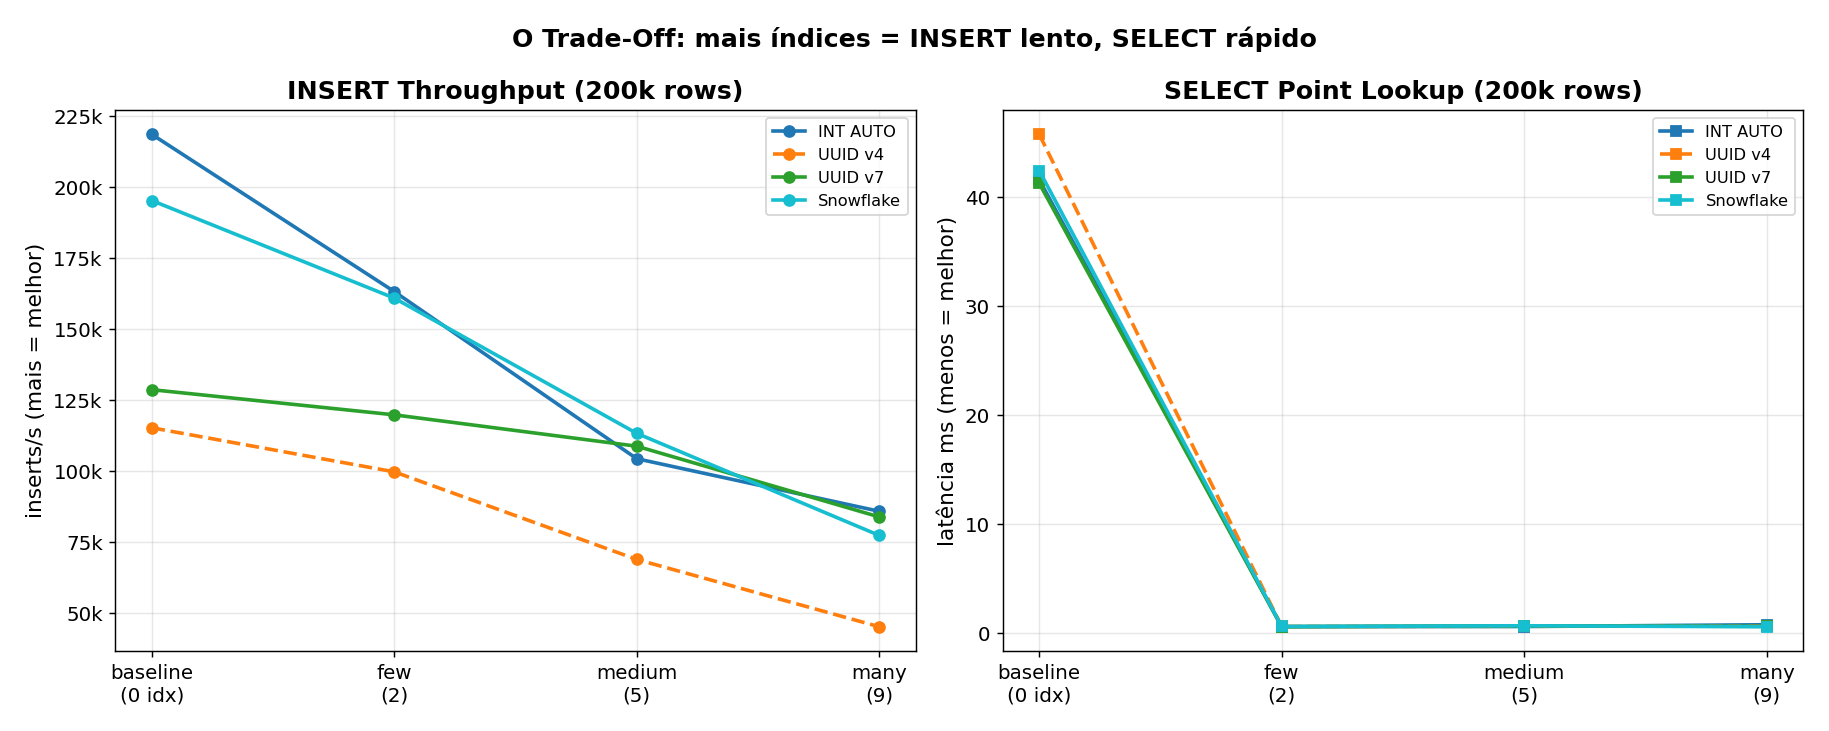

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("O Trade-Off: mais índices = INSERT lento, SELECT rápido", fontsize=14, fontweight="bold")

# LEFT: INSERT throughput
ax = axes[0]
ax.set_title("INSERT Throughput (200k rows)")
df_ins = b1[b1["rows"] == 200000]
x = np.arange(len(SCENARIOS))
for idt in ["INT AUTO", "UUID v4", "UUID v7", "Snowflake"]:
    sub = df_ins[df_ins["id_type"]==idt].set_index("scenario").reindex(SCENARIOS)
    ls = "--" if idt == "UUID v4" else "-"
    ax.plot(x, sub["throughput"].values, color=COLORS[idt], linewidth=2, linestyle=ls,
            marker="o", markersize=6, label=idt)
ax.set_xticks(x)
ax.set_xticklabels(["baseline\n(0 idx)", "few\n(2)", "medium\n(5)", "many\n(9)"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s (mais = melhor)")
ax.legend(fontsize=9)

# RIGHT: SELECT point_lookup
ax = axes[1]
ax.set_title("SELECT Point Lookup (200k rows)")
sub_sel = b3[b3["query"] == "point_lookup"]
for idt in ["INT AUTO", "UUID v4", "UUID v7", "Snowflake"]:
    vals = [sub_sel[(sub_sel["id_type"]==idt)&(sub_sel["scenario"]==s)]["avg_ms"].values[0] for s in SCENARIOS]
    ls = "--" if idt == "UUID v4" else "-"
    ax.plot(x, vals, color=COLORS[idt], linewidth=2, linestyle=ls,
            marker="s", markersize=6, label=idt)
ax.set_xticks(x)
ax.set_xticklabels(["baseline\n(0 idx)", "few\n(2)", "medium\n(5)", "many\n(9)"])
ax.set_ylabel("latência ms (menos = melhor)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("12_tradeoff_insert_vs_select.png")
plt.show()

## 13. Heatmap: INSERT Throughput (200k rows)

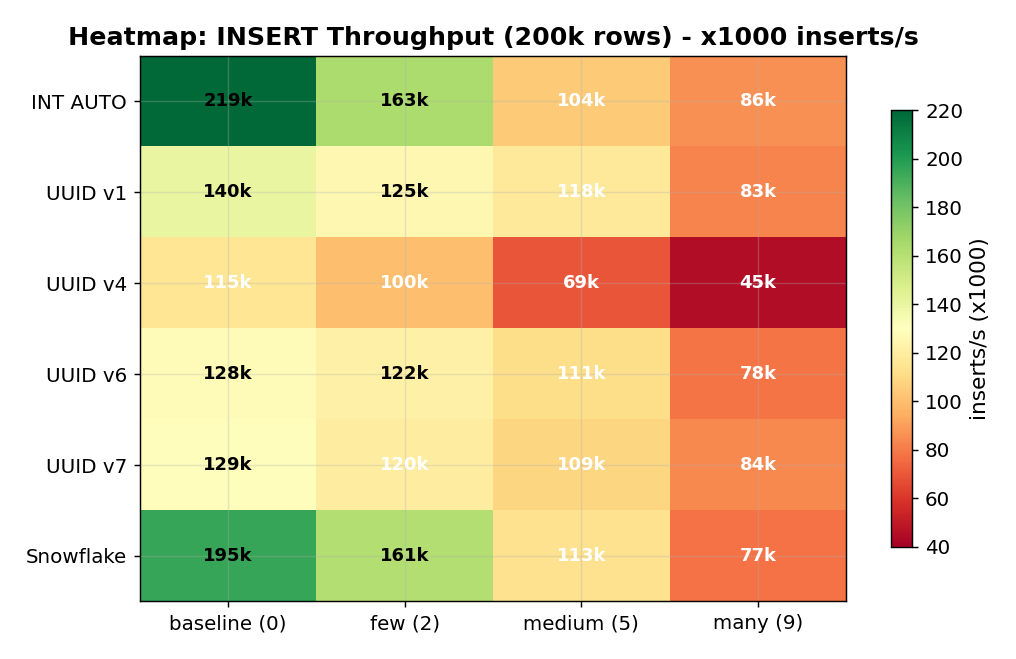

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title("Heatmap: INSERT Throughput (200k rows) - x1000 inserts/s")
data = np.array([
    [b1[(b1["id_type"]==t)&(b1["rows"]==200000)&(b1["scenario"]==s)]["throughput"].values[0]/1000
     for s in SCENARIOS] for t in ID_TYPES])
im = ax.imshow(data, cmap="RdYlGn", aspect="auto", vmin=40, vmax=220)
ax.set_xticks(range(len(SCENARIOS)))
ax.set_xticklabels(["baseline (0)","few (2)","medium (5)","many (9)"])
ax.set_yticks(range(len(ID_TYPES))); ax.set_yticklabels(ID_TYPES)
for i in range(len(ID_TYPES)):
    for j in range(len(SCENARIOS)):
        val = data[i,j]
        color = "black" if val > 120 else "white"
        ax.text(j, i, f"{val:.0f}k", ha="center", va="center", fontsize=10, fontweight="bold", color=color)
fig.colorbar(im, ax=ax, label="inserts/s (x1000)", shrink=0.8)
plt.tight_layout()
plt.savefig("13_heatmap_insert.png")
plt.show()

## 14. Heatmap: SELECT Point Lookup (200k rows)

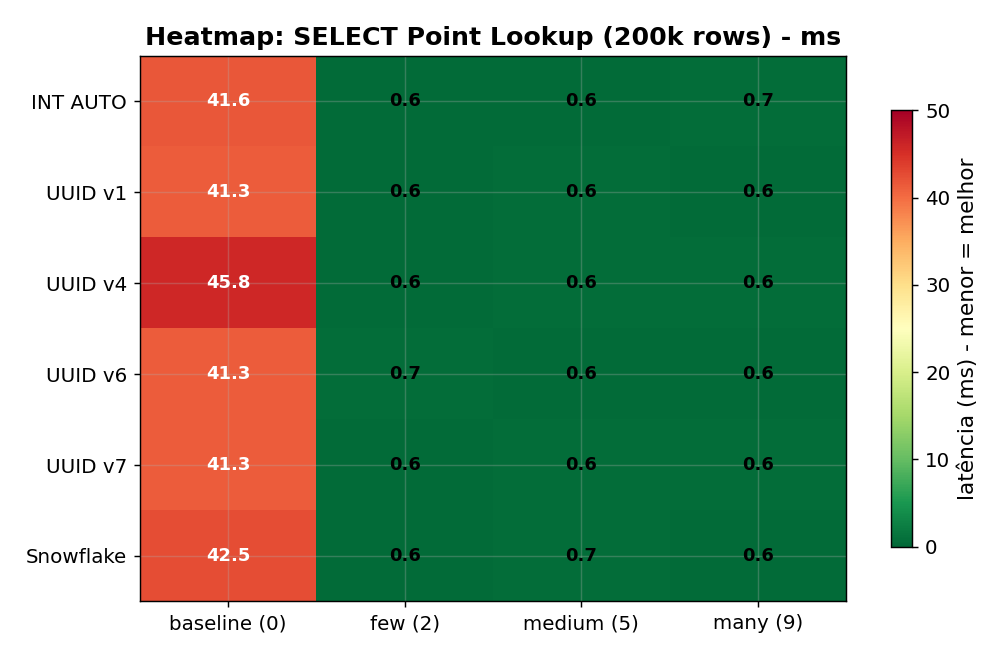

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title("Heatmap: SELECT Point Lookup (200k rows) - ms")
sub = b3[b3["query"] == "point_lookup"]
data = np.array([
    [sub[(sub["id_type"]==t)&(sub["scenario"]==s)]["avg_ms"].values[0]
     for s in SCENARIOS] for t in ID_TYPES])
im = ax.imshow(data, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=50)
ax.set_xticks(range(len(SCENARIOS)))
ax.set_xticklabels(["baseline (0)","few (2)","medium (5)","many (9)"])
ax.set_yticks(range(len(ID_TYPES))); ax.set_yticklabels(ID_TYPES)
for i in range(len(ID_TYPES)):
    for j in range(len(SCENARIOS)):
        val = data[i,j]
        color = "black" if val < 20 else "white"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=10, fontweight="bold", color=color)
fig.colorbar(im, ax=ax, label="latência (ms) - menor = melhor", shrink=0.8)
plt.tight_layout()
plt.savefig("14_heatmap_select.png")
plt.show()

## 15. Comparação Final: Melhor configuração de cada tipo

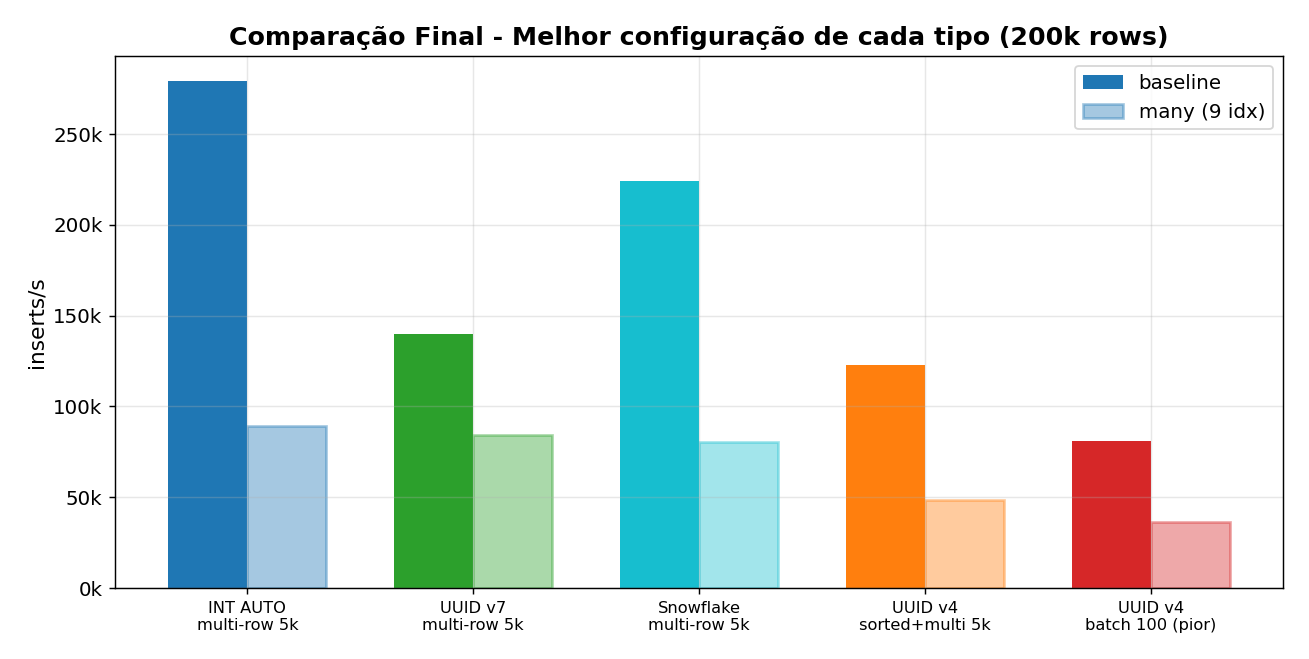

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Comparação Final - Melhor configuração de cada tipo (200k rows)")
configs = [
    ("INT AUTO\nmulti-row 5k",   279188, 89234, COLORS["INT AUTO"]),
    ("UUID v7\nmulti-row 5k",    139833, 84341, COLORS["UUID v7"]),
    ("Snowflake\nmulti-row 5k",  224247, 80317, COLORS["Snowflake"]),
    ("UUID v4\nsorted+multi 5k", 122808, 48714, COLORS["UUID v4"]),
    ("UUID v4\nbatch 100 (pior)",80751,  36559, "#d62728"),
]
x = np.arange(len(configs)); w = 0.35
ax.bar(x-w/2, [c[1] for c in configs], w, label="baseline",
       color=[c[3] for c in configs])
ax.bar(x+w/2, [c[2] for c in configs], w, label="many (9 idx)",
       color=[c[3] for c in configs], alpha=0.4,
       edgecolor=[c[3] for c in configs], linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels([c[0] for c in configs], fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylabel("inserts/s"); ax.legend()
plt.tight_layout()
plt.savefig("15_final_comparison.png")
plt.show()

## 16. Range Scan: INT/Snowflake (~58ms) vs UUID (~200ms)

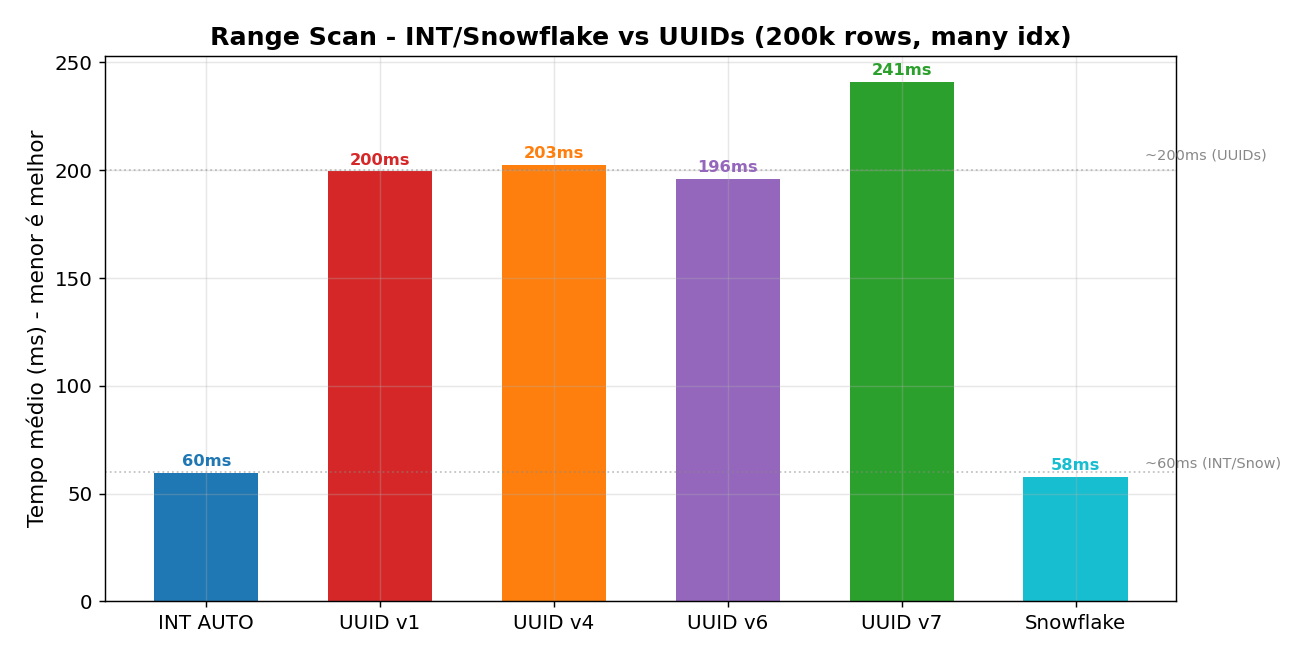

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Range Scan - INT/Snowflake vs UUIDs (200k rows, many idx)")
sub = b3[(b3["query"]=="range_scan")&(b3["scenario"]=="many")]
vals = [sub[sub["id_type"]==t]["avg_ms"].values[0] for t in ID_TYPES]
bar_colors = [COLORS[t] for t in ID_TYPES]
bars = ax.bar(range(len(ID_TYPES)), vals, color=bar_colors, width=0.6)
ax.set_xticks(range(len(ID_TYPES))); ax.set_xticklabels(ID_TYPES)
ax.set_ylabel("Tempo médio (ms) - menor é melhor")
for i, v in enumerate(vals):
    ax.text(i, v+3, f"{v:.0f}ms", ha="center", fontsize=9, fontweight="bold", color=bar_colors[i])
ax.axhline(y=60, color="#888", linestyle=":", linewidth=1, alpha=0.5)
ax.text(5.4, 62, "~60ms (INT/Snow)", fontsize=8, color="#888")
ax.axhline(y=200, color="#888", linestyle=":", linewidth=1, alpha=0.5)
ax.text(5.4, 205, "~200ms (UUIDs)", fontsize=8, color="#888")
plt.tight_layout()
plt.savefig("16_range_scan_comparison.png")
plt.show()